<a href="https://colab.research.google.com/github/ParhamPishro/Flavonoid/blob/main/4%20Hyperparameter%20Tuning/5_RF_HT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

Read Data

In [2]:
df = pd.read_excel("/content/FlavonoidData.xlsx")
df

,authors,flavonoid,cell line,time,dose,viability-mean,viability-error,viability-SD,viability-SE
0,Chen et al. 2017,Luteolin,KYSE30,48,10.0,77.272727,77.272727,0.001000,NaN
1,Chen et al. 2017,Luteolin,KYSE30,48,20.0,67.613636,67.613636,0.001000,NaN
2,Chen et al. 2017,Luteolin,KYSE30,48,40.0,47.159091,47.159091,0.001000,NaN
3,Chen et al. 2017,Luteolin,KYSE30,48,80.0,32.386364,32.386364,0.001000,NaN
4,Chen et al. 2017,Luteolin,KYSE30,72,10.0,69.886364,69.886364,0.001000,NaN
...,...,...,...,...,...,...,...,...,...
479,Zhu et al. 2016,Apigenin,KYSE150,24,20.0,88.407643,88.407643,0.001000,NaN
480,Zhu et al. 2016,Apigenin,KYSE150,24,40.0,78.980892,82.802548,3.821656,NaN
481,Zhu et al. 2016,Apigenin,KYSE150,24,60.0,67.261146,70.828025,3.566879,NaN
482,Zhu et al. 2016,Apigenin,KYSE150,24,80.0,45.350318,47.643312,2.292994,NaN


Discretized Data

In [3]:
df['v01'] = 1
df.loc[df['viability-mean']>50, 'v01'] = 0

In [4]:
df = df.drop(['authors', 'viability-error', 'viability-SD', 'viability-SE'], axis=1)
df

,flavonoid,cell line,time,dose,viability-mean,v01
0,Luteolin,KYSE30,48,10.0,77.272727,0
1,Luteolin,KYSE30,48,20.0,67.613636,0
2,Luteolin,KYSE30,48,40.0,47.159091,1
3,Luteolin,KYSE30,48,80.0,32.386364,1
4,Luteolin,KYSE30,72,10.0,69.886364,0
...,...,...,...,...,...,...
479,Apigenin,KYSE150,24,20.0,88.407643,0
480,Apigenin,KYSE150,24,40.0,78.980892,0
481,Apigenin,KYSE150,24,60.0,67.261146,0
482,Apigenin,KYSE150,24,80.0,45.350318,1


Encoding

In [5]:
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded

,time,dose,viability-mean,v01,flavonoid_Acacetin,flavonoid_Apigenin,flavonoid_Chrysin,flavonoid_Galangin,flavonoid_Kaempferol,flavonoid_Luteolin,...,cell line_KYSE150,cell line_KYSE30,cell line_KYSE410,cell line_KYSE450,cell line_KYSE510,cell line_OE19,cell line_OE33,cell line_TE-1,cell line_TE-10,cell line_YES2
0,48,10.0,77.272727,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
1,48,20.0,67.613636,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,48,40.0,47.159091,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3,48,80.0,32.386364,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,72,10.0,69.886364,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,24,20.0,88.407643,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
480,24,40.0,78.980892,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
481,24,60.0,67.261146,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
482,24,80.0,45.350318,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [6]:
X = df_encoded.drop(['viability-mean', 'v01'], axis=1)
y = df['viability-mean']
y01 = df['v01']

Initialize

In [7]:
rfc = RandomForestClassifier()

Hyperparameter Tuning

In [8]:
param_rf = {'criterion': ['gini', 'entropy'],
         'max_depth': range(1, 21),
         'min_samples_split': [2],
         'min_samples_leaf': [1],
         'n_estimators': range(5, 101, 5),
         'random_state': [2]}

gs_rf = GridSearchCV(rfc, param_rf, cv = 5, scoring = "accuracy")
%time gs_rf.fit(X, y01)
print(gs_rf.best_params_)
print(gs_rf.best_score_)

CPU times: user 7min 18s, sys: 1.34 s, total: 7min 19s
Wall time: 7min 23s
{'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 5, 'random_state': 2}
0.8906142611683849


In [9]:
param_rf = {'criterion': ['gini', 'entropy'],
         'max_depth': [11],
         'min_samples_split': [2],
         'min_samples_leaf': [1],
         'n_estimators': [5],
         'random_state': [2]}

rf_dt = GridSearchCV(rfc, param_rf, cv = 5, scoring = "accuracy")
%time rf_dt.fit(X, y01)

print(rf_dt.cv_results_['params'])
print(rf_dt.cv_results_['mean_test_score'])

CPU times: user 176 ms, sys: 996 µs, total: 177 ms
Wall time: 177 ms
[{'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 5, 'random_state': 2}, {'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 5, 'random_state': 2}]
[0.89061426 0.86585052]


CPU times: user 3.32 s, sys: 6.91 ms, total: 3.33 s
Wall time: 3.33 s


Text(0.5, 1.0, 'Random Forest')

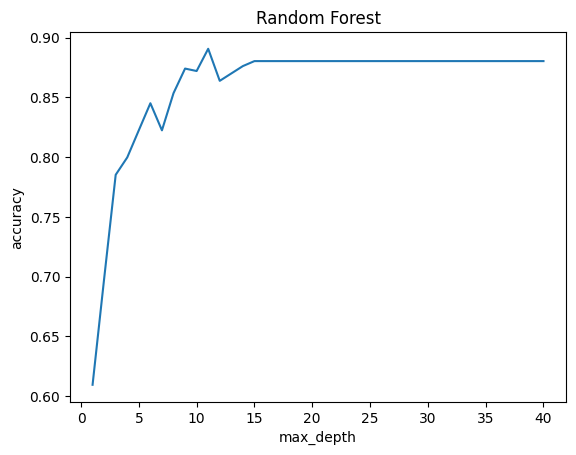

In [10]:
param_rf = {'criterion': ['gini'],
         'max_depth': range(1, 41),
         'min_samples_split': [2],
         'min_samples_leaf': [1],
         'n_estimators': [5],
         'random_state': [2]}

gs_rf = GridSearchCV(rfc, param_rf, cv = 5, scoring = "accuracy")
%time gs_rf.fit(X, y01)

plt.plot(range(1, 41), gs_rf.cv_results_['mean_test_score'])

plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('Random Forest')

CPU times: user 11.3 s, sys: 29 ms, total: 11.3 s
Wall time: 11.4 s


Text(0.5, 1.0, 'Random Forest')

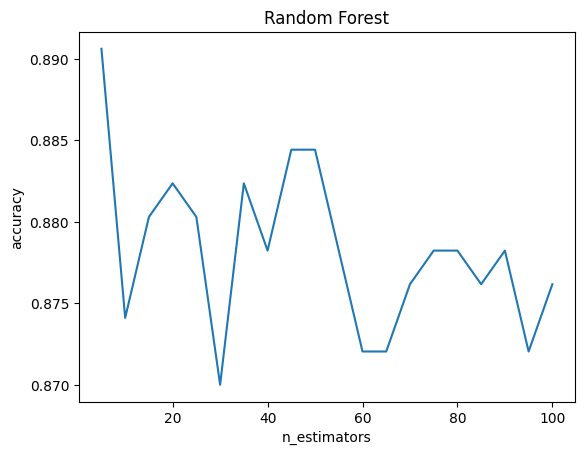

In [11]:
param_rf = {'criterion': ['gini'],
         'max_depth': [11],
         'min_samples_split': [2],
         'min_samples_leaf': [1],
         'n_estimators': range(5, 101, 5),
         'random_state': [2]}

gs_rf = GridSearchCV(rfc, param_rf, cv = 5, scoring = "accuracy")
%time gs_rf.fit(X, y01)

plt.plot(range(5, 101, 5), gs_rf.cv_results_['mean_test_score'])

plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.title('Random Forest')

In [12]:
param_rf = {'criterion': ['gini'],
         'max_depth': range(1, 41),
         'min_samples_split': [2],
         'min_samples_leaf': [1],
         'n_estimators': range(5, 101, 5),
         'random_state': [2]}

gs_rf = GridSearchCV(rfc, param_rf, cv = 5, scoring = "accuracy")
%time gs_rf.fit(X, y01)
print(gs_rf.best_params_)
print(gs_rf.best_score_)

CPU times: user 7min 25s, sys: 1.42 s, total: 7min 27s
Wall time: 7min 32s
{'criterion': 'gini', 'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 5, 'random_state': 2}
0.8906142611683849


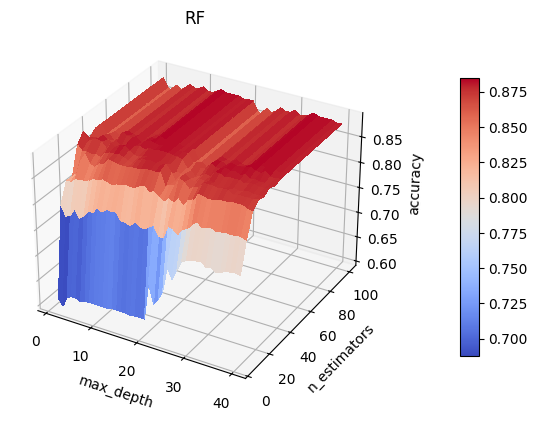

In [13]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data.
x_3d = range(1, 41)
y_3d = range(5, 101, 5)
x_3d, y_3d = np.meshgrid(x_3d, y_3d)
z_3d = gs_rf.cv_results_['mean_test_score'].reshape(20,40)

# Plot the surface.
surf = ax.plot_surface(x_3d, y_3d, z_3d, cmap=cm.coolwarm, linewidth=0, antialiased=False)

ax.set_xlabel('max_depth')
ax.set_ylabel('n_estimators')
ax.set_zlabel('accuracy')

plt.title('RF')

# Add a color bar which maps values to colors.
fig.colorbar(surf, location='right', shrink=0.75, aspect=15, anchor=(1.0, 0.5))

plt.show()

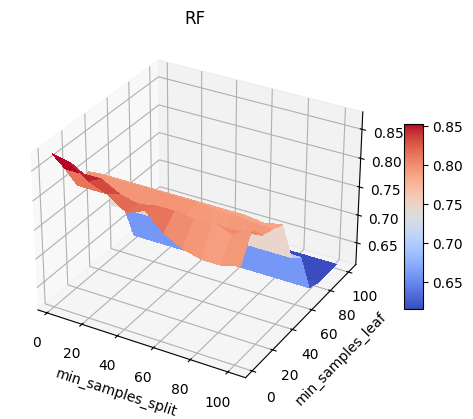

In [14]:
param_rf = {'criterion': ['gini'],
         'max_depth': [12],
         'min_samples_split': range(2, 103, 10),
         'min_samples_leaf': range(1, 102, 10),
         'n_estimators': [30],
         'random_state': [20]}

gs_rf = GridSearchCV(rfc, param_rf, cv = 5, scoring = "accuracy")
gs_rf.fit(X, y01)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data.
x_3d = range(2, 103, 10)
y_3d = range(1, 102, 10)
x_3d, y_3d = np.meshgrid(x_3d, y_3d)
z_3d = gs_rf.cv_results_['mean_test_score'].reshape(11,11)

# Plot the surface.
surf = ax.plot_surface(x_3d, y_3d, z_3d, cmap=cm.coolwarm, linewidth=0, antialiased=False)

# Customize the z axis.
#ax.set_zlim(0.7, 0.9)
#ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
#ax.zaxis.set_major_formatter('{x:.1f}')

ax.set_xlabel('min_samples_split')
ax.set_ylabel('min_samples_leaf')
ax.set_zlabel('accuracy')
#plt.xlabel('gamma')
#plt.ylabel('C')
#plt.zlabel('gamma')
plt.title('RF')

# Add a color bar which maps values to colors.
fig.colorbar(surf, location='right', shrink=0.5, aspect=10)

plt.show()